# Business Analysis

This section brings together findings from the previous analyses to examine key relationships across customers, orders, delivery, reviews, sellers, and products.

In [2]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

reviews = pd.read_csv(
    DATA_DIR / "olist_order_reviews_dataset.csv"
)

delivered_orders = orders[
    (orders["order_status"] == "delivered")
    & (orders["order_delivered_customer_date"].notna())
].copy()

date_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

delivered_orders[date_columns] = delivered_orders[date_columns].apply(
    pd.to_datetime
)

delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

order_reviews = (
    reviews
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

delivery_reviews = delivered_orders[
    ["order_id", "delivery_delay_days"]
].merge(
    order_reviews,
    on="order_id",
    how="inner"
)

In [3]:
delivery_reviews.shape

(95824, 3)

In [4]:
delivery_reviews[
    ["delivery_delay_days", "review_score"]
].corr()

,delivery_delay_days,review_score
delivery_delay_days,1.000000,-0.266908
review_score,-0.266908,1.000000


In [5]:
delivery_reviews["delay_group"] = pd.cut(
    delivery_reviews["delivery_delay_days"],
    bins=[-float("inf"), 0, 3, 7, 14, float("inf")],
    labels=[
        "On-time",
        "1-3 days late",
        "4-7 days late",
        "8-14 days late",
        "15+ days late"
    ]
)

In [6]:
delay_review = (
    delivery_reviews
    .groupby("delay_group", observed=False)
    .agg(
        orders=("order_id", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
)

delay_review

,orders,avg_review_score,median_review_score
delay_group,,,
On-time,88163,4.294292,5.0
1-3 days late,2636,3.766882,4.0
4-7 days late,1773,2.317259,1.0
8-14 days late,1748,1.745423,1.0
15+ days late,1504,1.710771,1.0


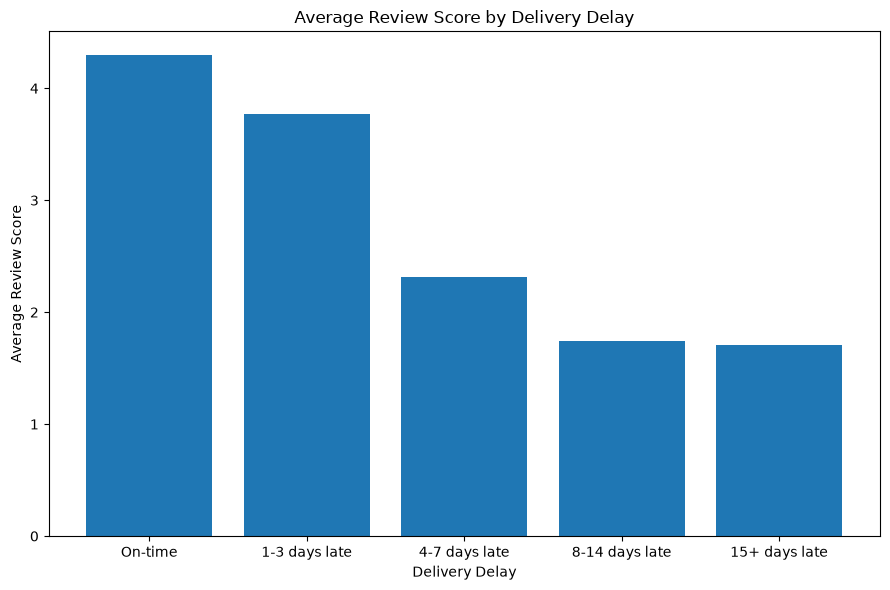

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.bar(
    delay_review.index,
    delay_review["avg_review_score"]
)

plt.title("Average Review Score by Delivery Delay")
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

## Key Finding

Delivery delays are strongly associated with lower customer satisfaction. The correlation between delivery delay and review score is -0.27, while average review scores decline from 4.29 for on-time orders to 1.71 for orders delivered 15 or more days late.

The sharpest decline occurs after the first few days of delay, suggesting that prolonged delivery delays have a substantial negative impact on customer satisfaction.

## Seller Revenue and Delivery Performance

This analysis examines whether high-revenue sellers also maintain reliable delivery performance, highlighting potential operational risks associated with seller concentration.

In [8]:
order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

In [9]:
seller_delivery = (
    order_items[
        ["order_id", "seller_id", "price"]
    ]
    .merge(
        delivery_reviews[
            ["order_id", "delivery_delay_days"]
        ],
        on="order_id",
        how="inner"
    )
)

In [10]:
seller_delivery_performance = (
    seller_delivery
    .groupby("seller_id")
    .agg(
        items_sold=("order_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_delivery_delay=("delivery_delay_days", "mean"),
        late_rate=("delivery_delay_days", lambda x: (x > 0).mean())
    )
    .reset_index()
)

In [11]:
seller_delivery_performance[
    ["revenue", "avg_delivery_delay", "late_rate"]
].corr()

,revenue,avg_delivery_delay,late_rate
revenue,1.000000,0.002773,-0.002995
avg_delivery_delay,0.002773,1.000000,0.569526
late_rate,-0.002995,0.569526,1.000000


In [12]:
seller_delivery_performance.sort_values(
    "revenue",
    ascending=False
).head(10)

,seller_id,items_sold,orders,revenue,avg_delivery_delay,late_rate
833,4869f7a5dfa277a7dca6462dcf3b52b2,1140,1116,225586.34,-10.480533,0.114912
980,53243585a1d6dc2643021fd1853d8905,398,346,215904.44,-10.936256,0.037688
857,4a3ca9315b744ce9f8e9374361493884,1927,1753,194699.12,-8.944784,0.110016
2898,fa1c13f2614d7b5c4749cbc52fecda94,575,574,189649.54,-9.720309,0.097391
1478,7c67e1448b00f6e969d365cea6b010ab,1347,967,185170.23,-10.834356,0.095026
1502,7e93a43ef30c4f03f38b393420bc753a,321,318,165751.50,-11.551403,0.052960
2538,da8622b14eb17ae2831f4ac5b9dab84a,1542,1305,159087.47,-10.579626,0.070687
1448,7a67c85e85bb2ce8582c35f2203ad736,1147,1137,138608.77,-11.172187,0.058413
188,1025f0e2d44d7041d6cf58b6550e0bfa,1408,902,137179.80,-10.420768,0.092330
1754,955fee9216a65b617aa5c0531780ce60,1462,1253,130753.82,-9.652231,0.080027


### Finding

No meaningful relationship was found between seller revenue and delivery performance. Revenue shows almost no correlation with either average delivery delay or late delivery rate.

This suggests that, in this dataset, high-revenue sellers are not systematically better or worse in terms of delivery performance.

## Product Category and Customer Satisfaction

This analysis examines whether customer satisfaction varies across product categories and identifies categories with relatively strong or weak review performance.

In [13]:
order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

products = pd.read_csv(
    DATA_DIR / "olist_products_dataset.csv"
)

In [14]:
category_reviews = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        delivery_reviews[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

In [15]:
category_reviews = (
    category_reviews[
        ["order_id", "product_category_name", "review_score"]
    ]
    .drop_duplicates()
    .dropna(subset=["product_category_name"])
)

In [16]:
category_review_summary = (
    category_reviews
    .groupby("product_category_name")
    .agg(
        orders=("order_id", "nunique"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .reset_index()
    .sort_values("orders", ascending=False)
)

In [17]:
category_review_summary.head(15)

,product_category_name,orders,avg_review_score,median_review_score
13,cama_mesa_banho,9177,3.999292,5.0
11,beleza_saude,8601,4.229489,5.0
32,esporte_lazer,7485,4.227589,5.0
44,informatica_acessorios,6498,4.081717,5.0
54,moveis_decoracao,6260,4.057987,5.0
72,utilidades_domesticas,5709,4.194430,5.0
66,relogios_presentes,5452,4.120873,5.0
70,telefonia,4069,4.051855,5.0
8,automotivo,3791,4.145608,5.0
12,brinquedos,3773,4.238139,5.0


In [18]:
category_review_main = category_review_summary[
    category_review_summary["orders"] >= 500
].sort_values("avg_review_score")

In [19]:
category_review_main.head(10)

,product_category_name,orders,avg_review_score,median_review_score
55,moveis_escritorio,1244,3.642685,4.0
13,cama_mesa_banho,9177,3.999292,5.0
70,telefonia,4069,4.051855,5.0
54,moveis_decoracao,6260,4.057987,5.0
44,informatica_acessorios,6498,4.081717,5.0
9,bebes,2787,4.103516,5.0
66,relogios_presentes,5452,4.120873,5.0
30,eletronicos,2498,4.124500,5.0
21,construcao_ferramentas_construcao,731,4.125171,5.0
8,automotivo,3791,4.145608,5.0


In [20]:
category_review_main.tail(10)

,product_category_name,orders,avg_review_score,median_review_score
32,esporte_lazer,7485,4.227589,5.0
11,beleza_saude,8601,4.229489,5.0
45,instrumentos_musicais,605,4.234711,5.0
12,brinquedos,3773,4.238139,5.0
33,fashion_bolsas_e_acessorios,1811,4.242131,5.0
31,eletroportateis,604,4.256623,5.0
62,perfumaria,3076,4.260891,5.0
63,pet_shop,1680,4.273810,5.0
59,papelaria,2251,4.294758,5.0
50,malas_acessorios,1015,4.370443,5.0


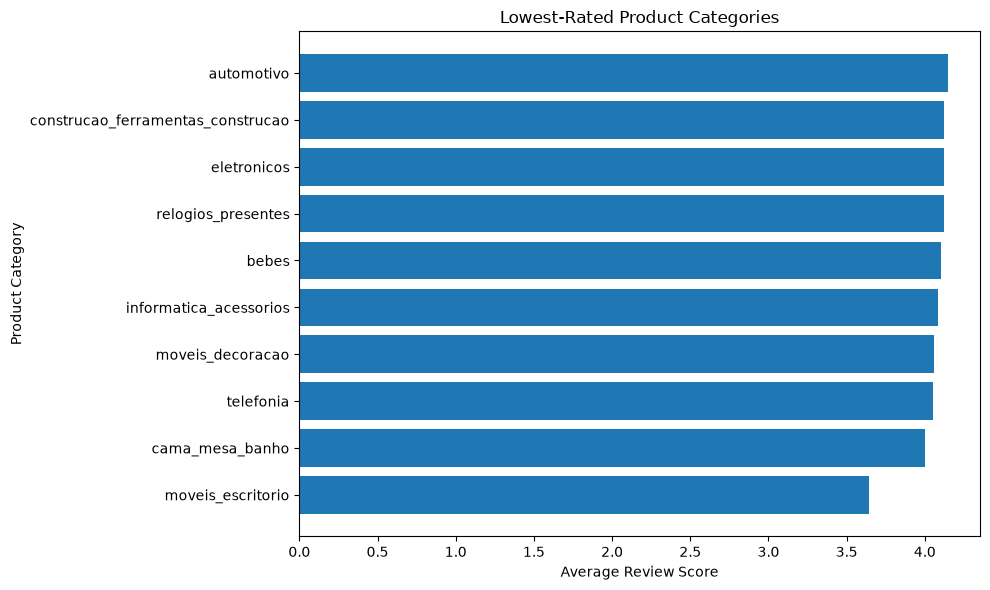

In [21]:
bottom_categories = category_review_main.head(10).sort_values(
    "avg_review_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    bottom_categories["product_category_name"],
    bottom_categories["avg_review_score"]
)

plt.title("Lowest-Rated Product Categories")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

## Key Finding

Customer satisfaction varies meaningfully across product categories. `moveis_escritorio` has the lowest average review score among categories with at least 500 orders, at 3.64, while most other high-volume categories score above 4.0.

This suggests that customer experience is not uniform across product categories and that low-rated categories may warrant further investigation into product quality, fulfillment, or seller performance.

## Customer Geography and Revenue

This analysis examines the geographic distribution of revenue across customer states to identify regions with a disproportionately large contribution to sales.

In [22]:
customers = pd.read_csv(
    DATA_DIR / "olist_customers_dataset.csv"
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

In [23]:
state_revenue = (
    orders[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_items[
            ["order_id", "price"]
        ],
        on="order_id",
        how="inner"
    )
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

In [24]:
state_revenue["revenue_share"] = (
    state_revenue["revenue"]
    / state_revenue["revenue"].sum()
)

In [25]:
state_revenue = state_revenue.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)

state_revenue.head(10)

,customer_state,orders,revenue,revenue_share
0,SP,41375,5202955.05,0.382805
1,RJ,12762,1824092.67,0.134207
2,MG,11544,1585308.03,0.116638
3,RS,5432,750304.02,0.055203
4,PR,4998,683083.76,0.050258
5,SC,3612,520553.34,0.038300
6,BA,3358,511349.99,0.037622
7,DF,2125,302603.94,0.022264
8,GO,2007,294591.95,0.021674
9,ES,2025,275037.31,0.020236


In [26]:
state_revenue.head(5)["revenue_share"].sum()

np.float64(0.7391117477571898)

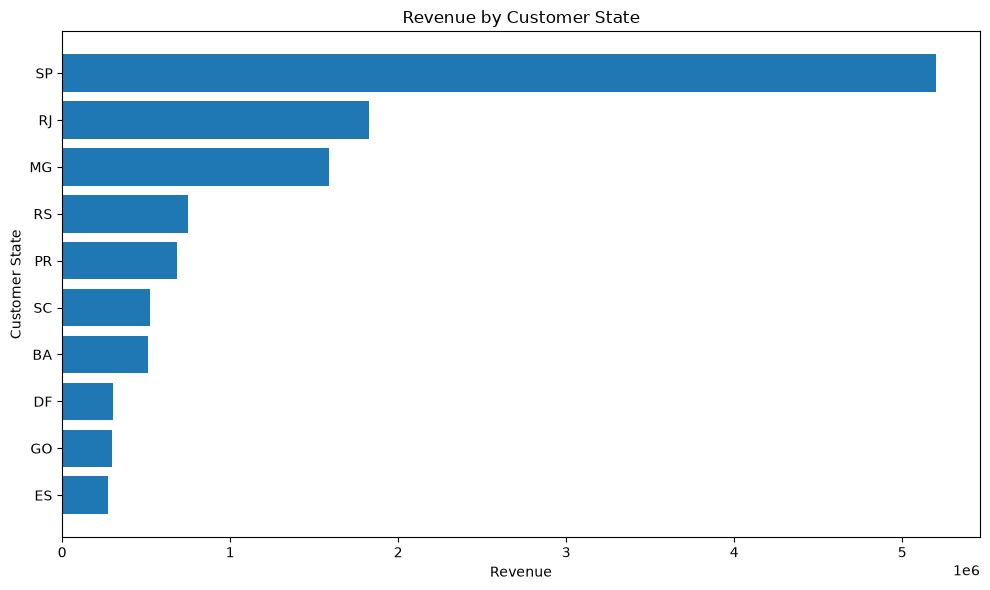

In [27]:
top_states = state_revenue.head(10).sort_values("revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    top_states["customer_state"],
    top_states["revenue"]
)

plt.title("Revenue by Customer State")
plt.xlabel("Revenue")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

## Key Finding

Revenue is geographically concentrated, with São Paulo (SP) alone accounting for 38.3% of total revenue. The five largest customer states contribute approximately 73.9% of total revenue.

This concentration indicates that business performance is strongly dependent on a relatively small number of geographic markets.

## Order Value and Payment Installments

This analysis examines the relationship between order value and the number of payment installments to understand how payment flexibility varies with purchase size.

In [28]:
payments = pd.read_csv(
    DATA_DIR / "olist_order_payments_dataset.csv"
)

In [29]:
order_payments = (
    payments
    .groupby("order_id")
    .agg(
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max")
    )
    .reset_index()
)

In [30]:
order_payment_value = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        order_value=("price", "sum")
    )
    .merge(
        order_payments,
        on="order_id",
        how="inner"
    )
)

In [31]:
order_payment_value[
    ["order_value", "max_installments"]
].corr()

,order_value,max_installments
order_value,1.000000,0.314274
max_installments,0.314274,1.000000


In [32]:
installment_summary = (
    order_payment_value
    .groupby("max_installments")
    .agg(
        orders=("order_id", "count"),
        avg_order_value=("order_value", "mean"),
        median_order_value=("order_value", "median")
    )
    .reset_index()
)

In [33]:
installment_summary

,max_installments,orders,avg_order_value,median_order_value
0,0,2,64.640000,64.640
1,1,47823,100.261659,59.990
2,2,12291,108.413328,89.990
3,3,10371,122.066925,91.280
4,4,7022,141.541434,99.700
5,5,5188,160.175918,107.850
6,6,3887,184.125948,119.900
7,7,1611,163.865922,110.990
8,8,4237,280.436660,189.000
9,9,635,172.889953,89.900


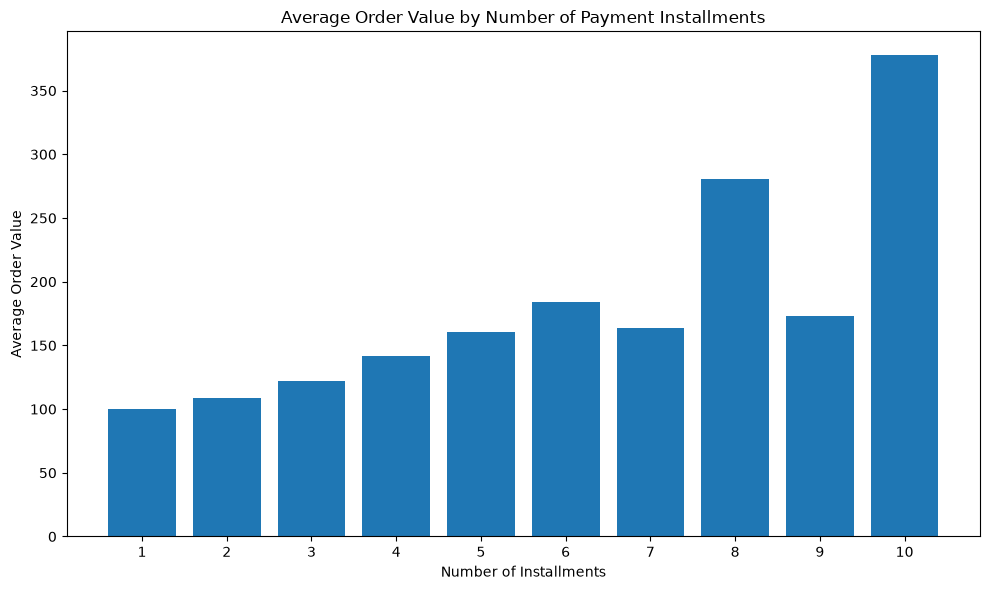

In [34]:
installment_plot = installment_summary[
    installment_summary["max_installments"].between(1, 10)
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    installment_plot["max_installments"].astype(str),
    installment_plot["avg_order_value"]
)

plt.title("Average Order Value by Number of Payment Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

## Key Finding

Higher-value orders tend to use more payment installments. The correlation between order value and the number of installments is 0.31, while average order value increases from 100.26 for one-installment orders to 377.66 for ten-installment orders.

Although the relationship is not perfectly linear, the overall pattern suggests that installment-based payment flexibility is more common among higher-value purchases.

# Business Takeaways

The cross-analysis highlights several important business patterns:

1. **Delivery performance is closely linked to customer satisfaction.**  
   Longer delivery delays are associated with substantially lower review scores, with the sharpest decline occurring after the first few days of delay.

2. **Customer satisfaction varies across product categories.**  
   Some categories consistently receive lower review scores than others, suggesting that category-level differences may warrant further investigation.

3. **Revenue is geographically concentrated.**  
   A large share of revenue comes from a relatively small number of customer states, creating geographic concentration in the business.

4. **Higher-value orders tend to use more payment installments.**  
   The positive relationship between order value and installment count suggests that payment flexibility is more common among higher-value purchases.

5. **Seller revenue is not meaningfully related to delivery performance.**  
   High-revenue sellers are not systematically better or worse in terms of delivery reliability based on the available data.